# Text Preprocessing and Tokenization


Cleaning a corpus of tweets with regular expressions and NLTK, then comparing three levels of tokenization — word, character and subword — on vocabulary size and out-of-vocabulary rate.

Coursework for ICS472 (Natural Language Processing), KFUPM.


## Packages


In [89]:
import re
import nltk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from wordcloud import WordCloud
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
import sentencepiece as spm

In [2]:
!pip install sentencepiece

Here we download some reqiured resources:

1- nltk.download('punkt'):
Downloads the Punkt Sentence Tokenizer, which is required for splitting text into sentences and words in multiple languages.

2- nltk.download('stopwords'):
Provides a corpus of stopwords (common words like "the," "is," "and") for multiple languages, often used to remove irrelevant words during text preprocessing.

3- nltk.download('wordnet'):
Downloads the WordNet Lexical Database, a dictionary for finding word meanings, synonyms, antonyms, and relationships, used for lemmatization and other advanced NLP tasks.

4- nltk.download('omw-1.4'):
Provides the Open Multilingual WordNet, offering translations of WordNet data into other languages, enabling multilingual lemmatization and semantic analysis.


In [90]:
# Download required NLTK resources
# Download the 'punkt' resource for tokenization
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

## Preprocessing


### Exploring the dataset

In [91]:
#Reading data
data = pd.read_csv("tweets_sentiment_analysis.csv")
data.head()

,tweet,sentiment
0,thanks will try to behave,positive
1,Today is lame because I am not in Orlando I a...,negative
2,hahahaha! i laughed my **** off just now. thanks,positive
3,Gahh ! This weather sucksss !,negative
4,Fallen in love with enter shikari again. Might...,positive


In [92]:
data.shape

(16363, 2)

In [93]:
data.isnull().sum()

,0
tweet,0
sentiment,0


In [94]:
data= data.drop_duplicates()
data.shape

(16363, 2)

Text(0.5, 1.0, 'Class Distributions')

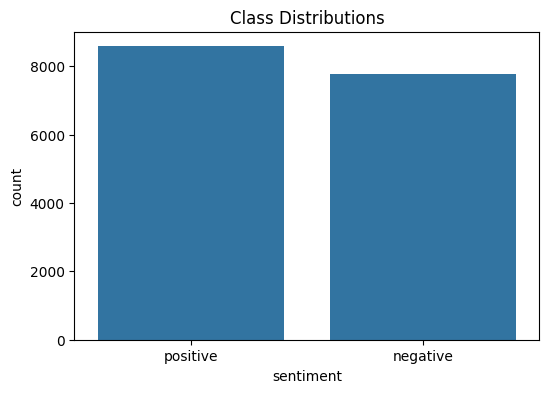

In [95]:
plt.figure(figsize=(6, 4))
sns.countplot(x='sentiment', data=data)
plt.title('Class Distributions')

In [96]:
data.head()

,tweet,sentiment
0,thanks will try to behave,positive
1,Today is lame because I am not in Orlando I a...,negative
2,hahahaha! i laughed my **** off just now. thanks,positive
3,Gahh ! This weather sucksss !,negative
4,Fallen in love with enter shikari again. Might...,positive


In [97]:
train_data, temp_data = train_test_split(data, test_size=0.3, random_state=42)  # 70% train,15% validation,15% test
val_data, test_data = train_test_split(temp_data, test_size=0.5, random_state=42)

### Text cleaning

The cleaning function uses regular expressions to strip the parts of a tweet that carry no sentiment signal:


Remove mentions, hashtags and URLs; strip special characters, numbers and punctuation; collapse repeated whitespace; lowercase.

1- Remove mentions (@username), hashtags (#hashtag), and URLs (http:// or https://).

2- Remove special characters, numbers, and punctuations.

3- Remove repeated characters (e.g., 'looooove' to 'love').

4- Convert text to lowercase.

5- Remove extra whitespaces.

In [98]:
import re

def clean_text(text):
    text = str(text)

    # 1. Remove mentions (@username), hashtags (#hashtag), and URLs
    # Using \w+ ensures the entire word following @ or # is removed
    text = re.sub(r"@\w+|#\w+|https?://\S+|www\.\S+", " ", text)

    # 2. Remove special characters, numbers, and punctuations
    # Replacing with a space prevents words from accidentally merging
    text = re.sub(r"[^a-zA-Z\s]+", " ", text)

    # 3. Remove repeated characters (e.g., 'looooove' to 'love')
    # We use {2,} to find a character followed by 2 or more of itself (3+ total)
    text = re.sub(r"([a-zA-Z])\1{2,}", r"\1", text)

    # 4. Convert text to lowercase
    text = text.lower()

    # 5. Remove extra whitespaces
    # This turns multiple spaces into one and trims the ends
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [99]:
# Apply cleaning
train_data['cleaned_tweet'] = train_data['tweet'].apply(clean_text)
val_data['cleaned_tweet'] = val_data['tweet'].apply(clean_text)
test_data['cleaned_tweet'] = test_data['tweet'].apply(clean_text)

In [100]:
train_data[['tweet', 'cleaned_tweet']].head()

,tweet,cleaned_tweet
15042,people in my house do not know how to close doors,people in my house do not know how to close doors
10955,thanks alot. Hope you can help spread the wor...,thanks alot hope you can help spread the word ...
5391,'The weather outside is weather' hahah made me...,the weather outside is weather hahah made me f...
11850,now the pic wont load up on twitter,now the pic wont load up on twitter
9640,ha! I know..I`m very ashamed.,ha i know i m very ashamed


In [101]:
# Remove empty rows after cleaning
def remove_empty_rows(df):
    df = df[df['cleaned_tweet'].str.strip() != '']
    df = df.reset_index(drop=True)
    return df

In [102]:
# Remove empty rows
train_data = remove_empty_rows(train_data)
val_data = remove_empty_rows(val_data)
test_data = remove_empty_rows(test_data)

In [103]:
train_data[['tweet', 'cleaned_tweet']].head()

,tweet,cleaned_tweet
0,people in my house do not know how to close doors,people in my house do not know how to close doors
1,thanks alot. Hope you can help spread the wor...,thanks alot hope you can help spread the word ...
2,'The weather outside is weather' hahah made me...,the weather outside is weather hahah made me f...
3,now the pic wont load up on twitter,now the pic wont load up on twitter
4,ha! I know..I`m very ashamed.,ha i know i m very ashamed


### Stopword removal

Stopwords are the highest-frequency function words in English. Removing them cuts token counts sharply, though as the vocabulary comparison later shows, it barely dents the number of distinct *types*.


The English stopword list comes from `nltk.corpus.stopwords`.

In [104]:
stop_words = set(stopwords.words('english'))

Splitting each tweet into words, dropping any that appear in the stopword set, and joining the remainder back.

In [105]:
# Function to remove stopwords
def remove_stopwords(sentence):
    words = str(sentence).split()
    filtered_words = [w for w in words if w not in stop_words]

    return ' '.join(filtered_words)  # Join the words back into a sentence

In [106]:
# Remove stopwords
train_data['cleaned_tweet_without_stopwords'] = train_data['cleaned_tweet'].apply(remove_stopwords)
val_data['cleaned_tweet_without_stopwords'] = val_data['cleaned_tweet'].apply(remove_stopwords)
test_data['cleaned_tweet_without_stopwords'] = test_data['cleaned_tweet'].apply(remove_stopwords)

In [107]:
train_data[['cleaned_tweet', 'cleaned_tweet_without_stopwords']].head()

,cleaned_tweet,cleaned_tweet_without_stopwords
0,people in my house do not know how to close doors,people house know close doors
1,thanks alot hope you can help spread the word ...,thanks alot hope help spread word get people i...
2,the weather outside is weather hahah made me f...,weather outside weather hahah made feel better
3,now the pic wont load up on twitter,pic wont load twitter
4,ha i know i m very ashamed,ha know ashamed


### Stemming and lemmatization

Two ways to collapse inflected forms onto a shared root.


`PorterStemmer` applies rule-based suffix stripping. `WordNetLemmatizer` maps words to dictionary head-words using WordNet, so it returns real words where the stemmer often does not.

The PorterStemmer is a rule-based stemming algorithm designed to reduce words to their root stems.

The WordNetLemmatizer uses WordNet, a lexical database of English, to reduce words to their lemmatized or dictionary base form (lemma) while ensuring the result is a valid word.

In [108]:
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

Both operate word by word over a split-and-rejoin.

In [109]:
# Function to apply stemming
def stem_text(sentence):
    words = str(sentence).split()
    stemmed_words = [stemmer.stem(w) for w in words]
    return ' '.join(stemmed_words)  # Join the words back into a sentence

# Function to apply lemmatization
def lemmatize_text(sentence):
    words = str(sentence).split()
    lemmatized_words = [lemmatizer.lemmatize(w) for w in words]
    return ' '.join(lemmatized_words)  # Join the words back into a sentence

In [110]:
# Apply stemming
train_data['stemmed_tweet'] = train_data['cleaned_tweet'].apply(stem_text)
val_data['stemmed_tweet'] = val_data['cleaned_tweet'].apply(stem_text)
test_data['stemmed_tweet'] = test_data['cleaned_tweet'].apply(stem_text)

In [111]:
# Apply lemmatization
train_data['lemmatized_tweet'] = train_data['cleaned_tweet'].apply(lemmatize_text)
val_data['lemmatized_tweet'] = val_data['cleaned_tweet'].apply(lemmatize_text)
test_data['lemmatized_tweet'] = test_data['cleaned_tweet'].apply(lemmatize_text)

In [112]:
train_data[['cleaned_tweet', 'stemmed_tweet', 'lemmatized_tweet']].head()

,cleaned_tweet,stemmed_tweet,lemmatized_tweet
0,people in my house do not know how to close doors,peopl in my hous do not know how to close door,people in my house do not know how to close door
1,thanks alot hope you can help spread the word ...,thank alot hope you can help spread the word a...,thanks alot hope you can help spread the word ...
2,the weather outside is weather hahah made me f...,the weather outsid is weather hahah made me fe...,the weather outside is weather hahah made me f...
3,now the pic wont load up on twitter,now the pic wont load up on twitter,now the pic wont load up on twitter
4,ha i know i m very ashamed,ha i know i m veri asham,ha i know i m very ashamed


### Word cloud


A word cloud, also known as a tag cloud, is a visual representation of text data where the size of each word indicates its frequency or importance in the given dataset. It is often used to summarize and visualize text data, making it easy to identify the most prominent words or themes.

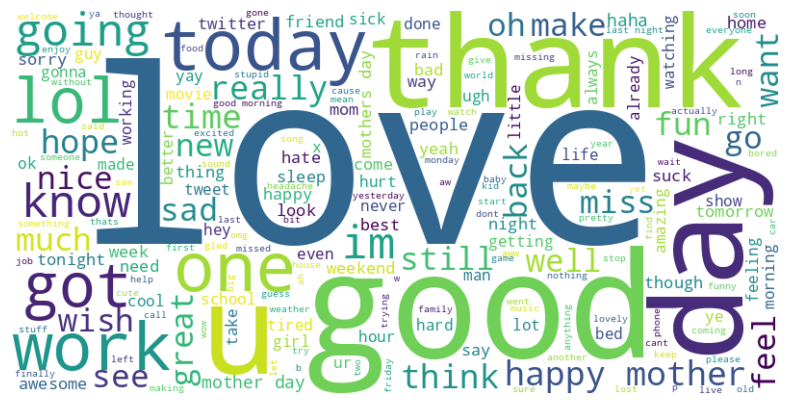

In [113]:
# Join all the cleaned tweets into one large string
all_words = ' '.join(train_data['cleaned_tweet_without_stopwords'])

# Generate the word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_words)

# Display the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

## Tokenization

Three levels of granularity, each fitted on the training split only and then applied to validation and test. The comparison of interest is vocabulary size against out-of-vocabulary rate.


### Helper functions


get_tokens_from_single_sequence and get_subword_tokens_from_sequence: Convert tokenized sequences back into words or subwords for interpretation.


calculate_oov_rate and calculate_oov_rate_BPE: Measure how often tokens in the data are classified as OOV by the tokenizer or subword processor.

In [114]:
def get_tokens_from_single_sequence(tokenizer, sequence):
    # Reverse the tokenizer's word index to map IDs back to words
    index_word = {index: word for word, index in tokenizer.word_index.items()}

    # Convert the sequence back to words using the word index
    tokens = [index_word[token] for token in sequence if token in index_word]

    return tokens

In [115]:
def calculate_oov_rate(tokenizer, tokenized_data, oov_token="<UNK>"):

    # Get the token ID for the OOV token
    oov_token_id = tokenizer.word_index.get(oov_token)

    # Count the number of OOV tokens in the tokenized data
    oov_count = sum(1 for sentence in tokenized_data for token in sentence if token == oov_token_id)

    # Calculate the total number of tokens
    total_tokens = sum(len(sentence) for sentence in tokenized_data)

    # Calculate and return the OOV rate
    return oov_count / total_tokens if total_tokens > 0 else 0

In [116]:
# Function to map token IDs back to subword tokens
def get_subword_tokens_from_sequence(sp_processor, sequence):
    subword_tokens = [sp_processor.id_to_piece(token_id) for token_id in sequence]
    return subword_tokens

In [117]:
# Define a function to calculate the OOV rate
def calculate_oov_rate_BPE(sp_processor, sequences):
    oov_token_id = sp_processor.unk_id()  # Get the ID of the <unk> token
    total_tokens = sum(len(seq) for seq in sequences)  # Total number of tokens
    oov_tokens = sum(seq.count(oov_token_id) for seq in sequences)  # Count OOV tokens
    oov_rate = oov_tokens / total_tokens if total_tokens > 0 else 0  # OOV rate calculation
    return oov_rate

### Word-level tokenizer


The word-level tokenizer is fitted on `cleaned_tweet`, with `<UNK>` reserved for tokens it has never seen.

In [118]:
tokenizer_word = Tokenizer(oov_token="<UNK>")
tokenizer_word.fit_on_texts(train_data['cleaned_tweet'])

Applied to the training, validation and test splits.

In [119]:
train_sequences_word = tokenizer_word.texts_to_sequences(train_data['cleaned_tweet'])
val_sequences_word = tokenizer_word.texts_to_sequences(val_data['cleaned_tweet'])
test_sequences_word = tokenizer_word.texts_to_sequences(test_data['cleaned_tweet'])

Vocabulary size is the number of distinct tokens the tokenizer learned, plus one for the padding index.

In [120]:
vocab_word_size = len(tokenizer_word.word_index) + 1
print("Word-Level Vocabulary Size:", vocab_word_size)

Word-Level Vocabulary Size: 13352


In [121]:
# Example of tokenized text from the train set
print("Sample Tweet:", train_data['cleaned_tweet'][0])
print("Word-Level Tokenization:", get_tokens_from_single_sequence(tokenizer_word, train_sequences_word[0]))

Sample Tweet: people in my house do not know how to close doors
Word-Level Tokenization: ['people', 'in', 'my', 'house', 'do', 'not', 'know', 'how', 'to', 'close', 'doors']


In [122]:
# Calculate OOV rates for word-level tokenizer
oov_rate_word_train = calculate_oov_rate(tokenizer_word, train_sequences_word)
oov_rate_word_val = calculate_oov_rate(tokenizer_word, val_sequences_word)
oov_rate_word_test = calculate_oov_rate(tokenizer_word, test_sequences_word)

print("Word-Level OOV Rate (Train):", oov_rate_word_train)
print("Word-Level OOV Rate (Validation):", oov_rate_word_val)
print("Word-Level OOV Rate (Test):", oov_rate_word_test)

Word-Level OOV Rate (Train): 0.0
Word-Level OOV Rate (Validation): 0.05187328662808407
Word-Level OOV Rate (Test): 0.05093899594942924


### Comparing the four preprocessing variants


The same tokenizer fitted separately on each of the four preprocessing variants: cleaned text, cleaned without stopwords, stemmed, and lemmatized.

In [124]:
tokenizer_word_without_stopwords = Tokenizer(oov_token="<UNK>")
tokenizer_word_without_stopwords.fit_on_texts(train_data['cleaned_tweet_without_stopwords'])

tokenizer_word_stemmed = Tokenizer(oov_token="<UNK>")
tokenizer_word_stemmed.fit_on_texts(train_data['stemmed_tweet'])

tokenizer_word_lemmatized = Tokenizer(oov_token="<UNK>")
tokenizer_word_lemmatized.fit_on_texts(train_data['lemmatized_tweet'])

Comparing the vocabulary each variant produces.

In [125]:
vocab_word_without_stopwords_size= len(tokenizer_word_without_stopwords.word_index) + 1
vocab_word_stemmed_size= len(tokenizer_word_stemmed.word_index) + 1
vocab_word_lemmatized_size= len(tokenizer_word_lemmatized.word_index) + 1

print("Word-Level Vocabulary Size:", vocab_word_size)
print("Word-Level Vocabulary Size (without stopwords):", vocab_word_without_stopwords_size)
print("Word-Level Vocabulary Size (stemmed):", vocab_word_stemmed_size)
print("Word-Level Vocabulary Size (lemmatized):", vocab_word_lemmatized_size)

Word-Level Vocabulary Size: 13352
Word-Level Vocabulary Size (without stopwords): 13205
Word-Level Vocabulary Size (stemmed): 10556
Word-Level Vocabulary Size (lemmatized): 12263


### Character-level tokenizer


The character-level tokenizer is fitted on the same cleaned text with `char_level=True`.

In [126]:
tokenizer_char = Tokenizer(char_level=True, oov_token="<UNK>")
tokenizer_char.fit_on_texts(train_data['cleaned_tweet'])

Applied to all three splits.

In [127]:
train_sequences_char = tokenizer_char.texts_to_sequences(train_data['cleaned_tweet'])
val_sequences_char = tokenizer_char.texts_to_sequences(val_data['cleaned_tweet'])
test_sequences_char = tokenizer_char.texts_to_sequences(test_data['cleaned_tweet'])

In [128]:
vocab_char_size = len(tokenizer_char.word_index) + 1
print("Character-Level Vocabulary Size:", vocab_char_size)

Character-Level Vocabulary Size: 29


In [129]:
# Example of tokenized text from the train set
print("Sample Tweet:", train_data['cleaned_tweet'][0])
print("Character-Level Tokenization:", get_tokens_from_single_sequence(tokenizer_char, train_sequences_char[0]))

Sample Tweet: people in my house do not know how to close doors
Character-Level Tokenization: ['p', 'e', 'o', 'p', 'l', 'e', ' ', 'i', 'n', ' ', 'm', 'y', ' ', 'h', 'o', 'u', 's', 'e', ' ', 'd', 'o', ' ', 'n', 'o', 't', ' ', 'k', 'n', 'o', 'w', ' ', 'h', 'o', 'w', ' ', 't', 'o', ' ', 'c', 'l', 'o', 's', 'e', ' ', 'd', 'o', 'o', 'r', 's']


In [130]:
# Calculate OOV rates for character-level tokenizer
oov_rate_char_train = calculate_oov_rate(tokenizer_char, train_sequences_char)
oov_rate_char_val = calculate_oov_rate(tokenizer_char, val_sequences_char)
oov_rate_char_test = calculate_oov_rate(tokenizer_char, test_sequences_char)

print("Character-Level OOV Rate (Train):", oov_rate_char_train)
print("Character-Level OOV Rate (Validation):", oov_rate_char_val)
print("Character-Level OOV Rate (Test):", oov_rate_char_test)

Character-Level OOV Rate (Train): 0.0
Character-Level OOV Rate (Validation): 0.0
Character-Level OOV Rate (Test): 0.0


### Subword tokenizer (BPE)


A SentencePiece BPE model trained on the cleaned training tweets, with a 5,000-piece vocabulary.

model_prefix parameter defines the prefix for the output model files.

After training, SentencePiece will generate files like:

tweets_bpe.model: The trained model file, which contains the tokenization rules.

tweets_bpe.vocab: The vocabulary file, listing the tokens (subwords) learned by the model along with their frequencies.

In [131]:
import sentencepiece as spm

with open('tweets_train.txt', 'w', encoding='utf-8') as f:
    for tweet in train_data['cleaned_tweet']:
        f.write(tweet + '\n')

spm.SentencePieceTrainer.train(input='tweets_train.txt', model_prefix='tweets_bpe', vocab_size=5000, model_type='bpe')

This will create two files: 'tweets_bpe.model' and 'tweets_bpe.vocab'.

Loading the trained model back.

In [132]:
sp = spm.SentencePieceProcessor()
sp.load("tweets_bpe.model")

True

Applied to all three splits.

In [133]:
train_sequences_bpe = [sp.encode_as_ids(t) for t in train_data["cleaned_tweet"].astype(str)]
val_sequences_bpe = [sp.encode_as_ids(t) for t in val_data["cleaned_tweet"].astype(str)]
test_sequences_bpe = [sp.encode_as_ids(t) for t in test_data["cleaned_tweet"].astype(str)]

In [134]:
vocab_size = sp.get_piece_size()

print("Subword (BPE) Vocabulary Size:", vocab_size)

Subword (BPE) Vocabulary Size: 5000


In [135]:
# Example tokenization from the train set
print("Sample Tweet:", train_data['cleaned_tweet'][0])
print("BPE Tokenization:", get_subword_tokens_from_sequence(sp,train_sequences_bpe[0]))

Sample Tweet: people in my house do not know how to close doors
BPE Tokenization: ['▁people', '▁in', '▁my', '▁house', '▁do', '▁not', '▁know', '▁how', '▁to', '▁close', '▁do', 'ors']


In [136]:
# Calculate OOV rates for the subword tokenizer (BPE)
oov_rate_bpe_train = calculate_oov_rate_BPE(sp, train_sequences_bpe)
oov_rate_bpe_val = calculate_oov_rate_BPE(sp, val_sequences_bpe)
oov_rate_bpe_test = calculate_oov_rate_BPE(sp, test_sequences_bpe)

print("BPE OOV Rate (Train):", oov_rate_bpe_train)
print("BPE OOV Rate (Validation):", oov_rate_bpe_val)
print("BPE OOV Rate (Test):", oov_rate_bpe_test)

BPE OOV Rate (Train): 0.0017283038176184656
BPE OOV Rate (Validation): 0.0017060367454068241
BPE OOV Rate (Test): 0.0014778455123637612
